In [86]:
# Import all libraries.
import os
import json
import numpy as np
import matplotlib.pyplot as plt

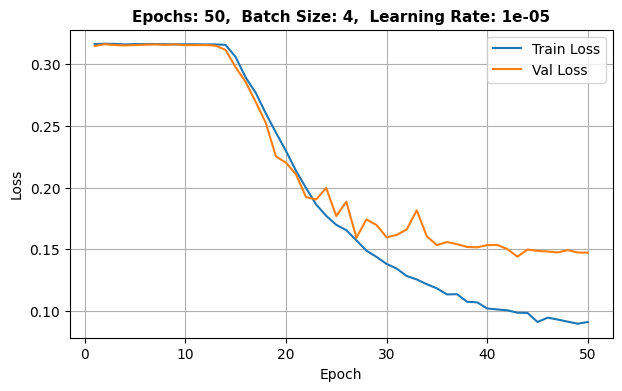

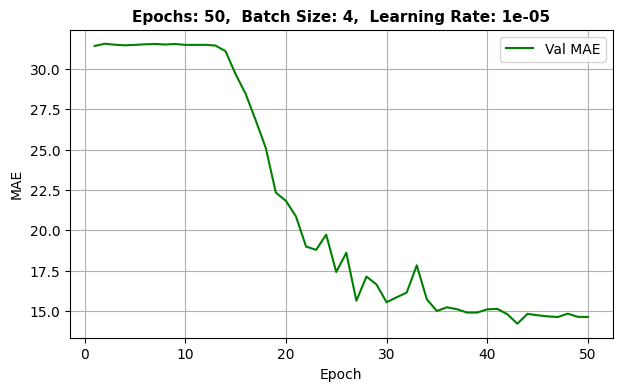

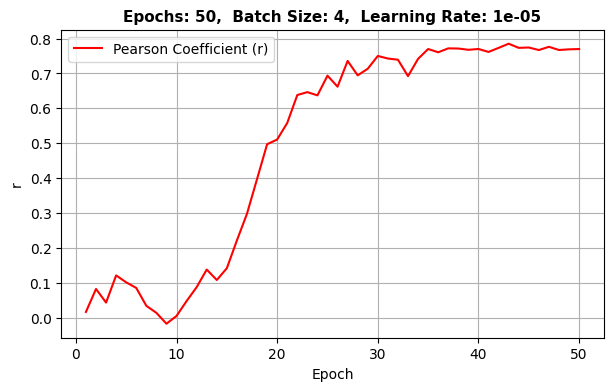

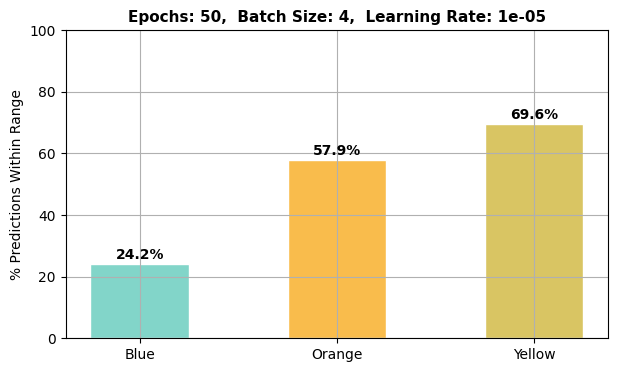

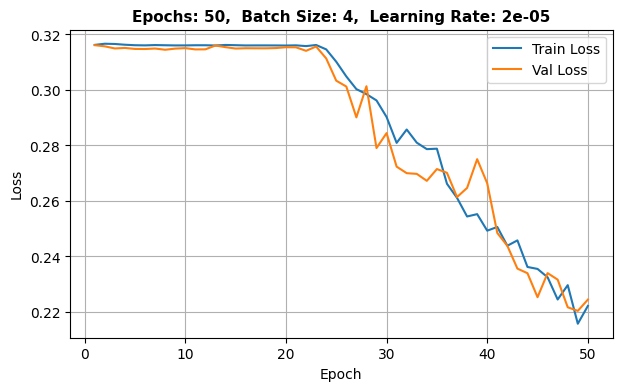

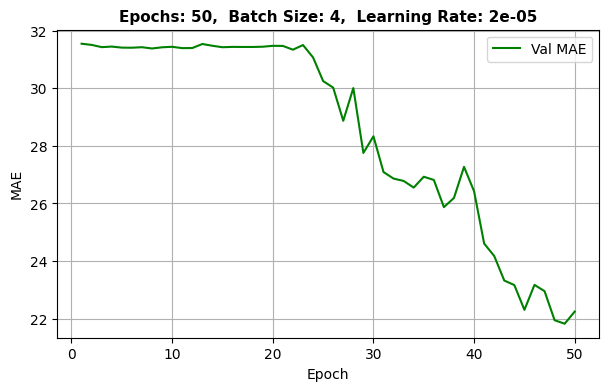

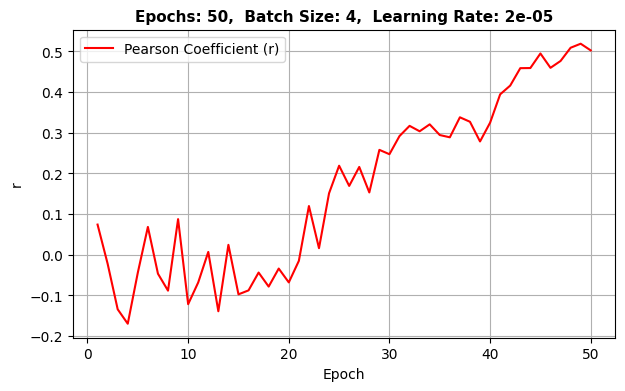

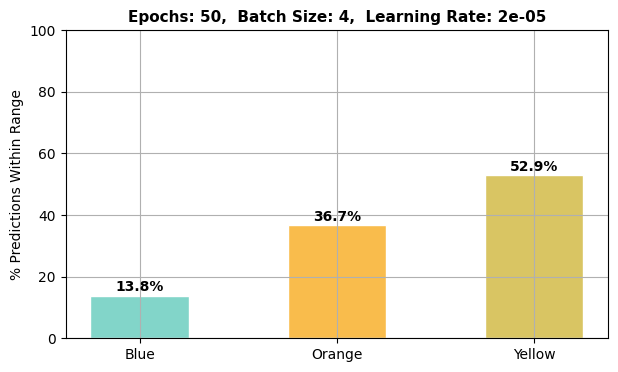

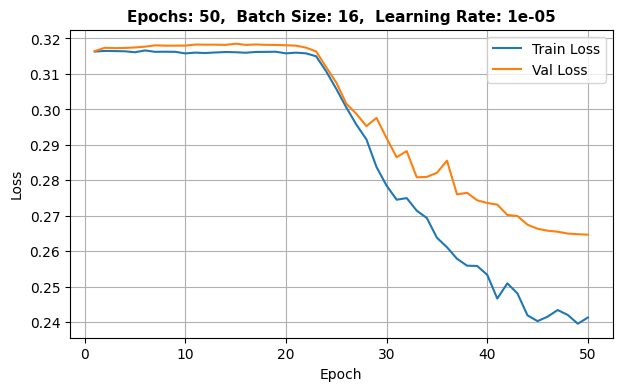

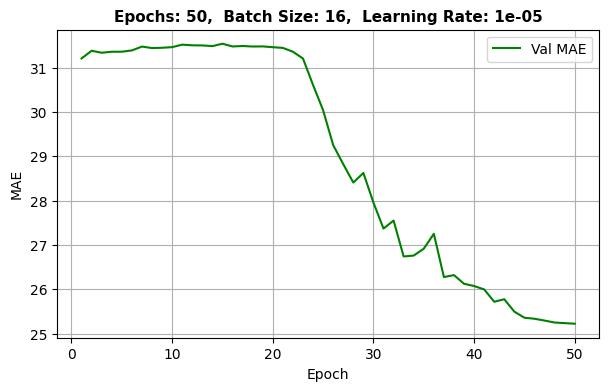

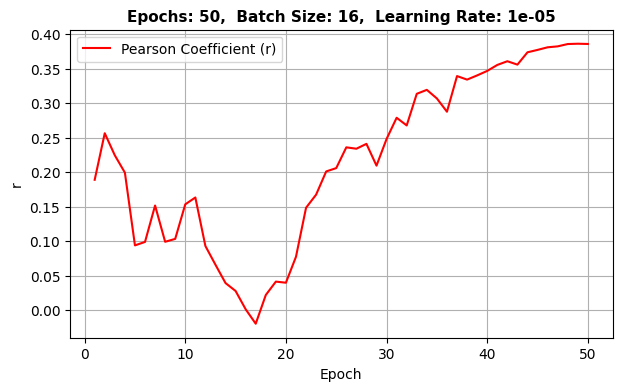

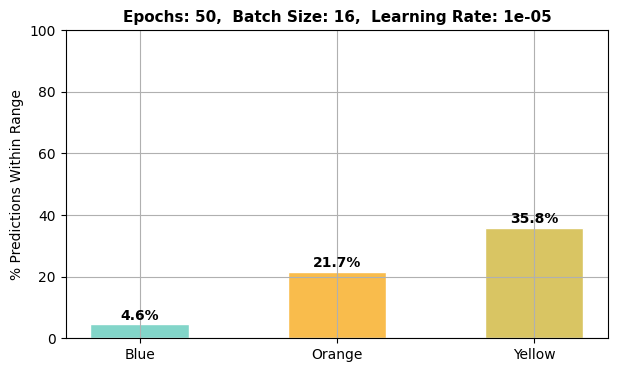

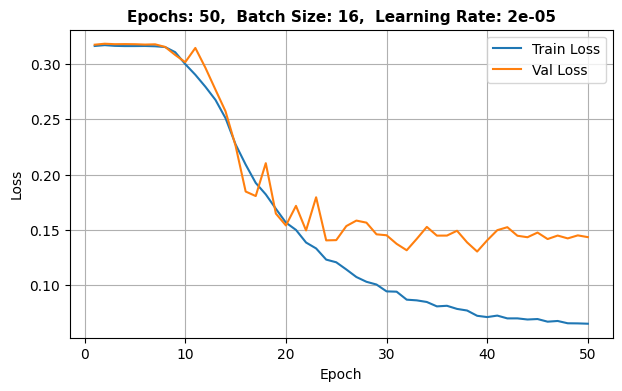

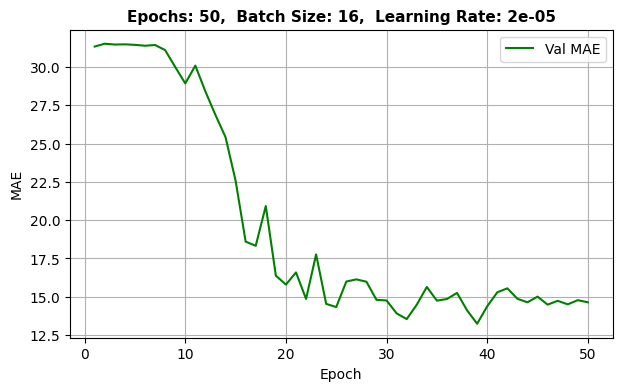

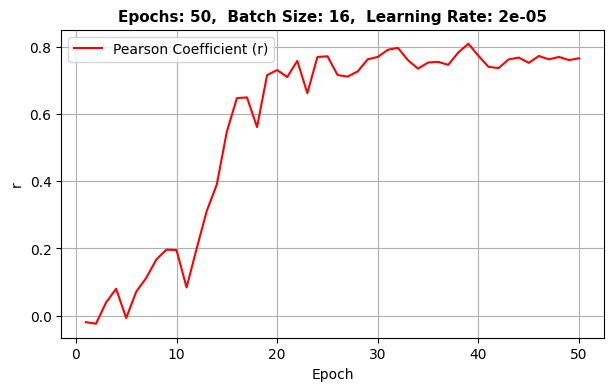

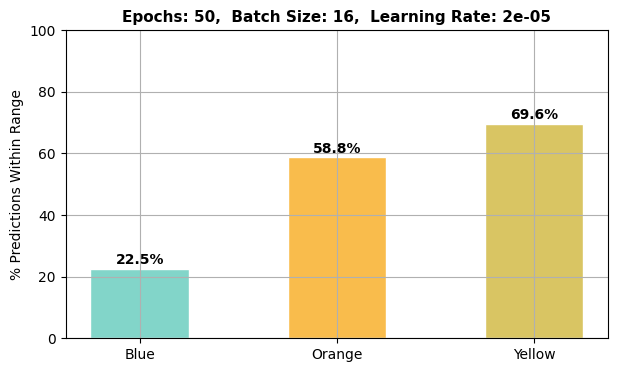

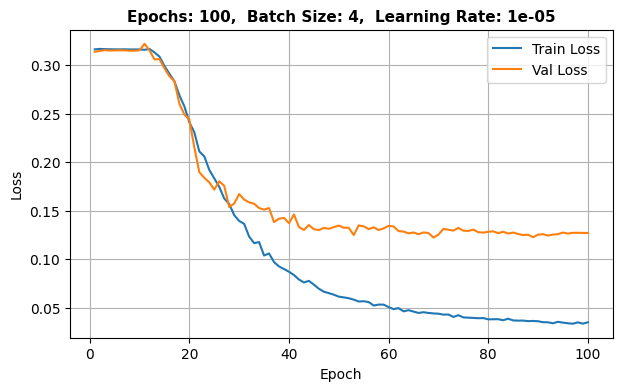

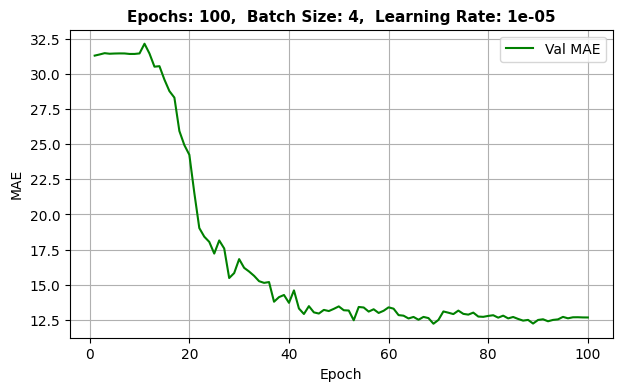

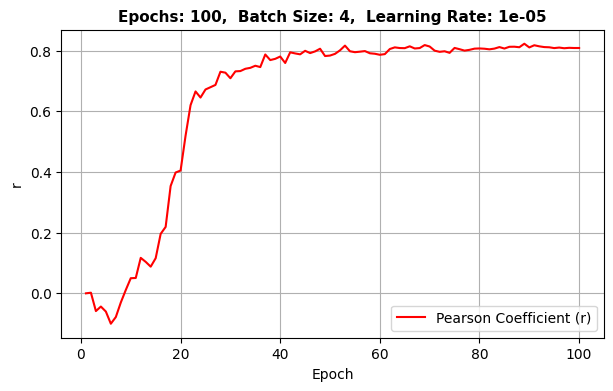

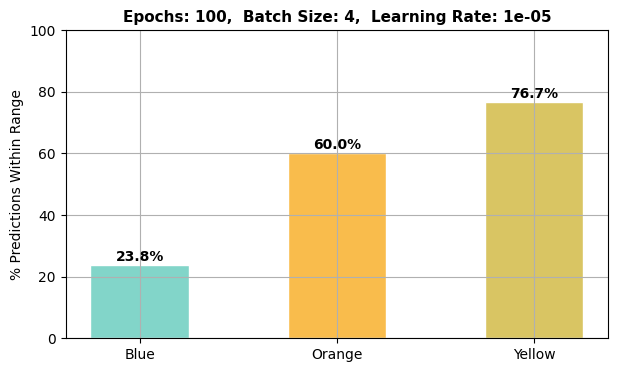

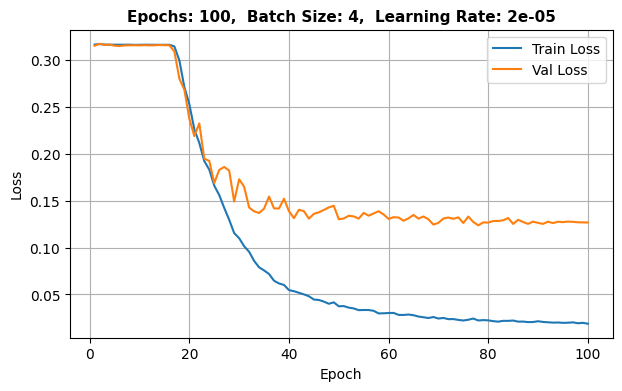

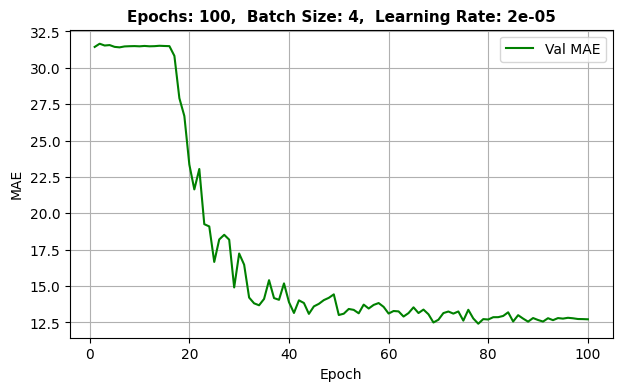

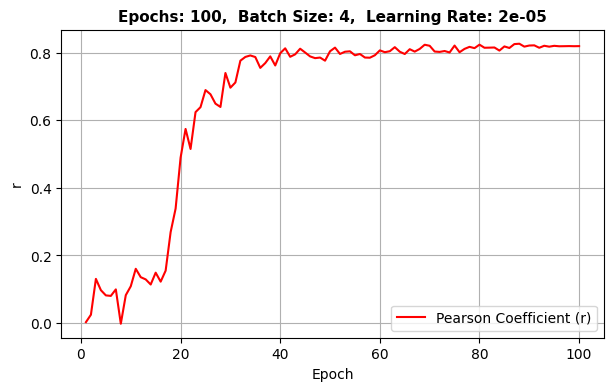

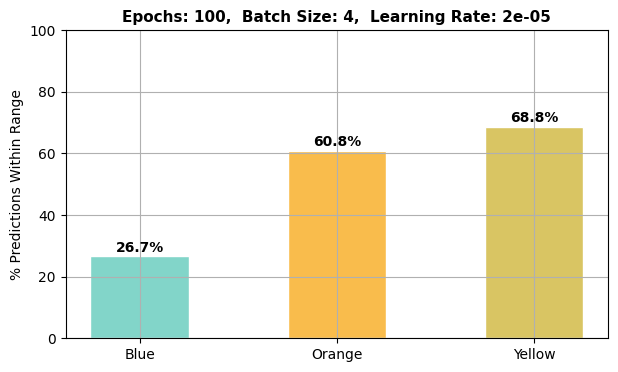

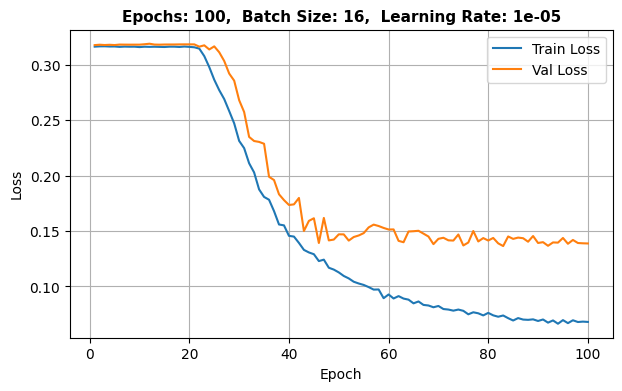

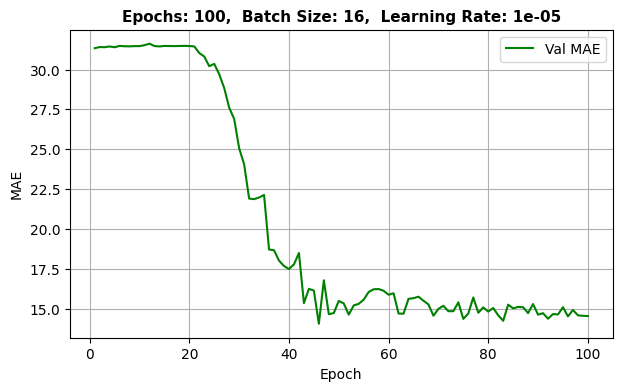

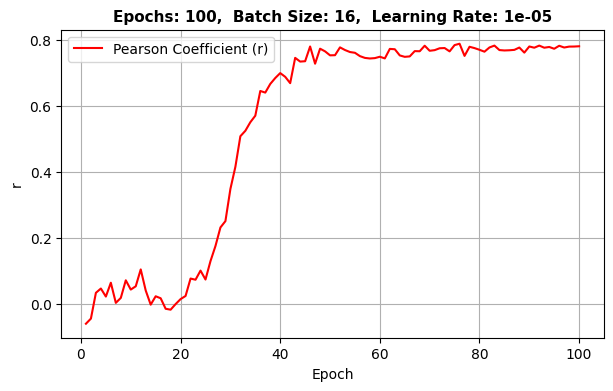

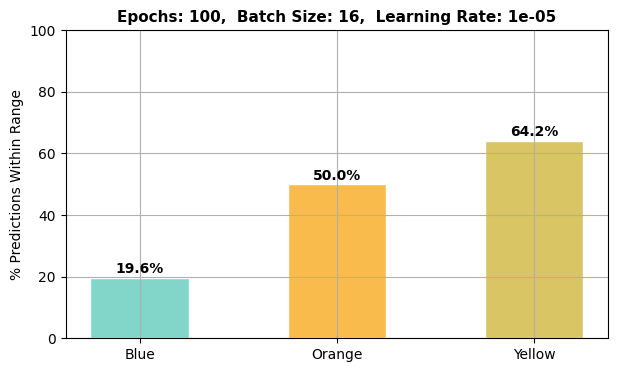

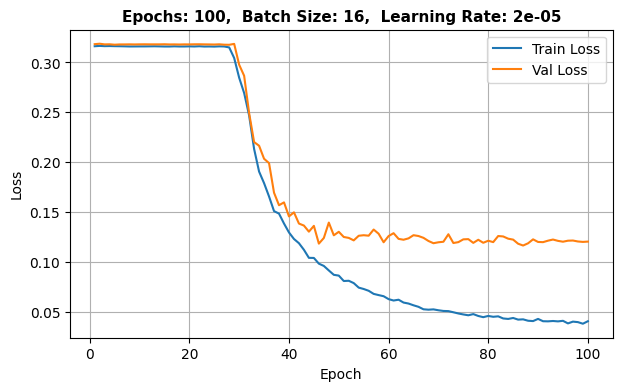

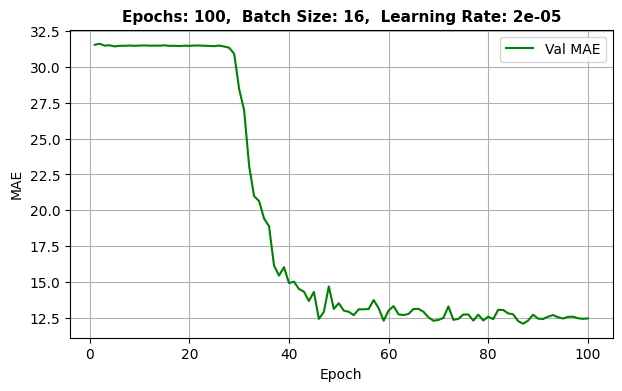

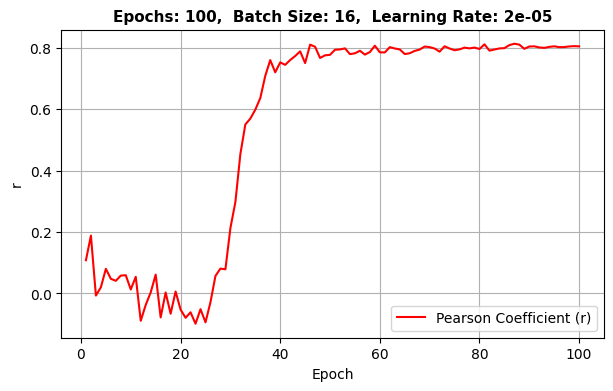

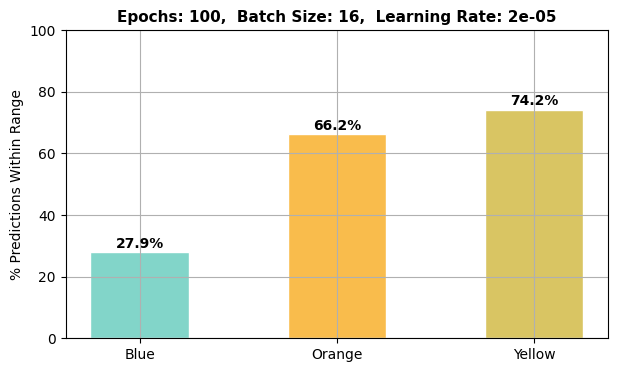

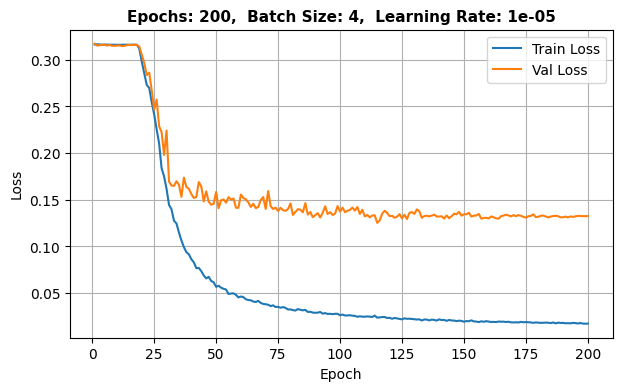

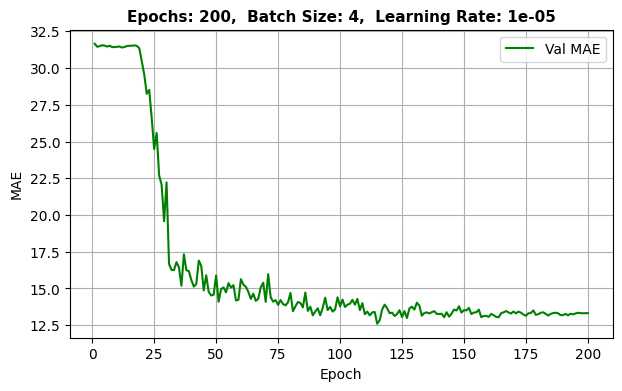

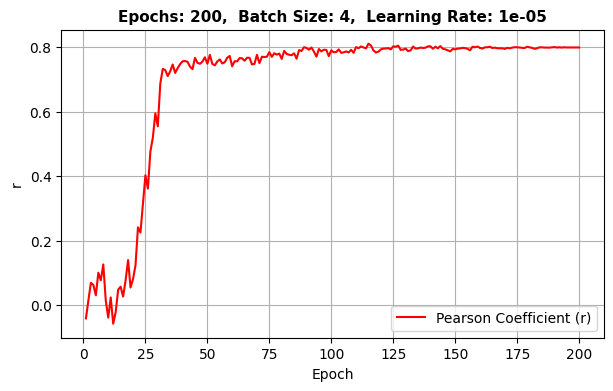

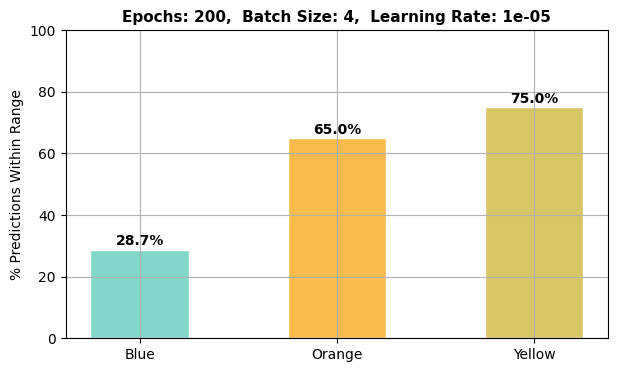

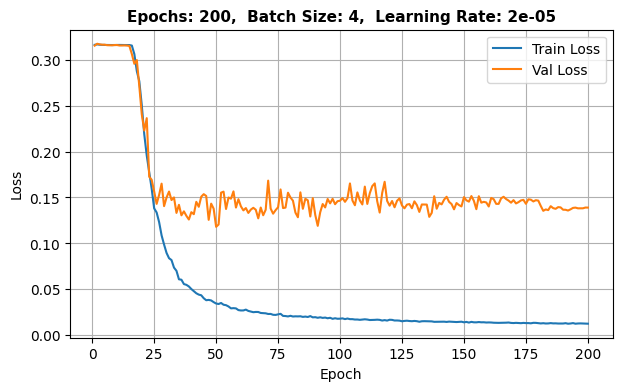

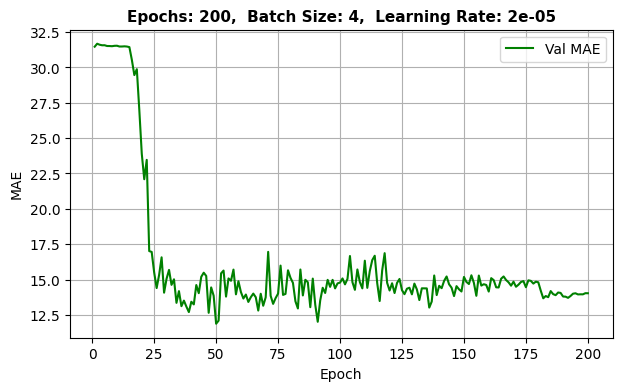

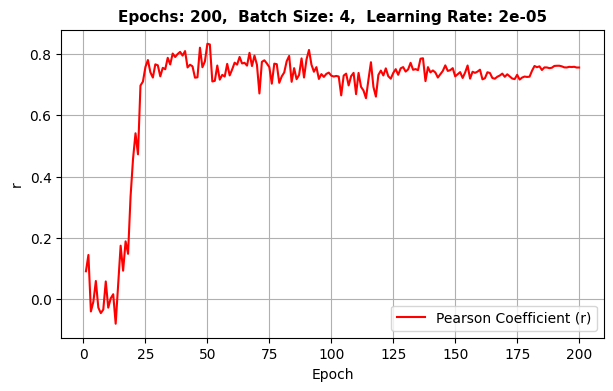

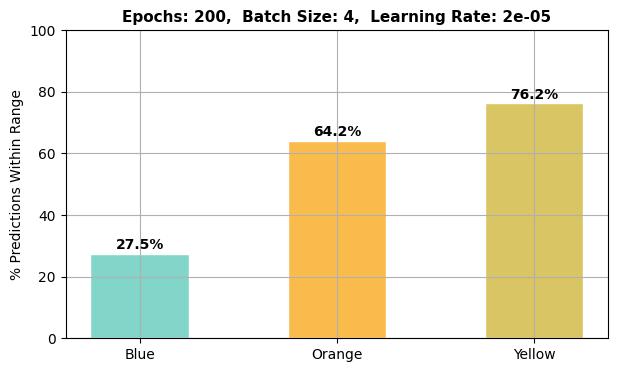

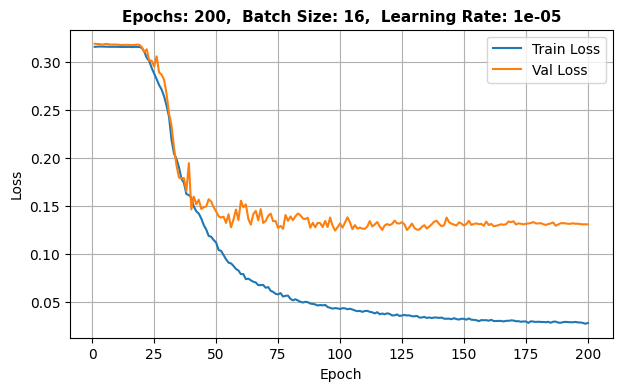

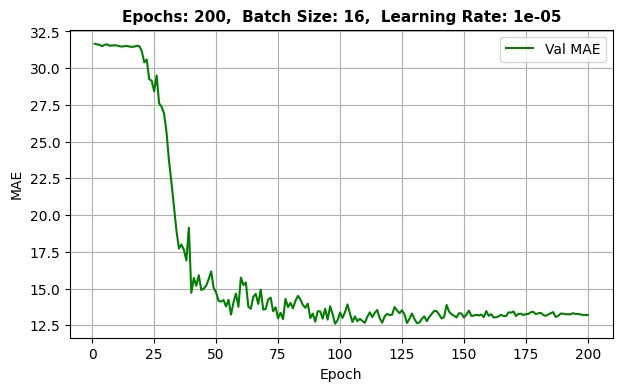

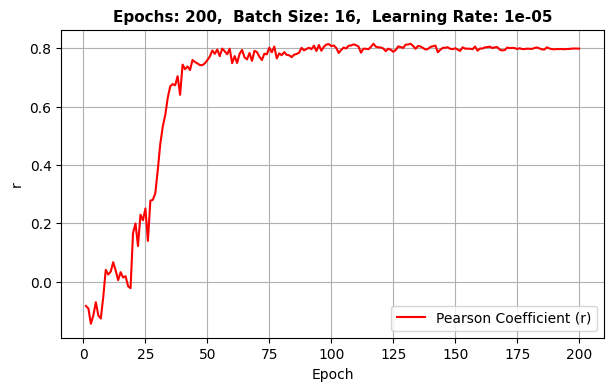

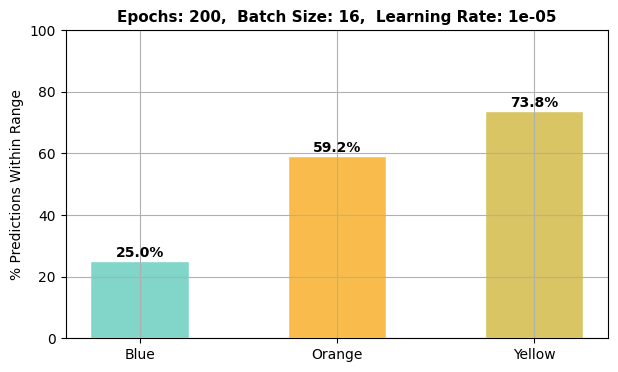

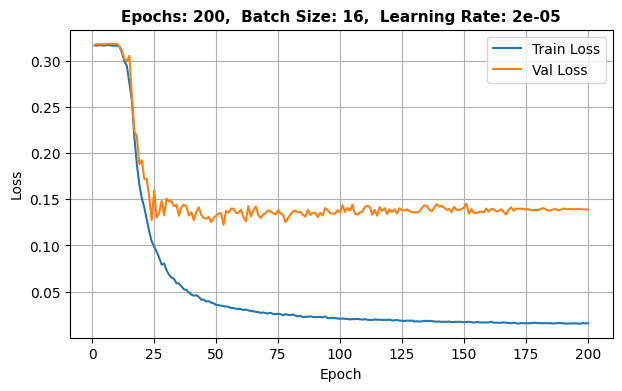

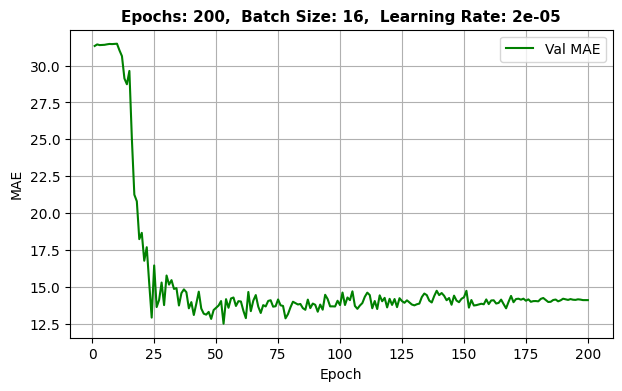

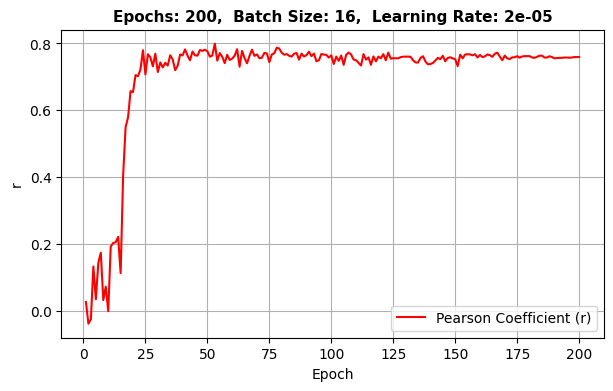

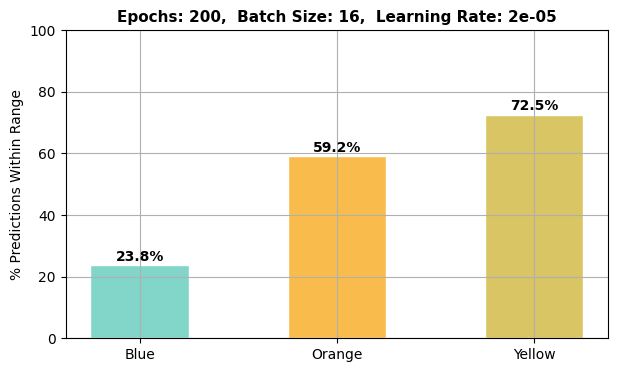

In [87]:
# All singular graphs per experiment.
history_directory = 'history/wally'
graphs_directory  = 'graphs/wally'
os.makedirs(graphs_directory, exist_ok = True)
experiments = []
exp_names   = []


# Sort history JSONS by ascending epochs, then ascending batch, then ascending lr.
def sort_key(filename):
    parts  = filename.replace('.json', '').split('_')
    epochs = int(parts[1].replace('epochs', ''))
    bs     = int(parts[2].replace('bs', ''))
    lr     = float(parts[3].replace('lr', ''))
    return (epochs, bs, lr)

files = sorted(os.listdir(history_directory), key = sort_key)
for file in files:
    
    # Make a folder for each experiment.
    experiment_folder = os.path.join(graphs_directory, file)
    os.makedirs(experiment_folder, exist_ok = True)

    # Open all JSONS.
    with open(os.path.join(history_directory, file)) as f:
  
  
        # Train/Validation Loss Graph:
        data = json.load(f)
        experiments.append(data)                                                                   
        exp_names.append(f"E{data['info']['epochs']}_B{data['info']['batch_size']}_LR{data['info']['lr']}") 

        total_epochs = data['info']['epochs']
        num_epochs   = np.arange(1, total_epochs + 1)
        batch_size   = data['info']['batch_size']
        lr           = data['info']['lr']
        
        train_losses = [epoch["train_loss"] for epoch in data["epoch_history"]]
        val_losses   = [epoch["val_loss"]   for epoch in data["epoch_history"]]
        val_maes     = [epoch["val_mae"]    for epoch in data["epoch_history"]]
        val_rs       = [epoch["val_r"]      for epoch in data["epoch_history"]]
        
        plt.figure(figsize = (7, 4))
        plt.plot(num_epochs, train_losses, label = "Train Loss")
        plt.plot(num_epochs, val_losses,   label = "Val Loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        # plt.suptitle("Train/Val Loss Graph", fontsize = 15, fontweight = 'bold', y = 1)
        plt.title(f"Epochs: {total_epochs},  Batch Size: {batch_size},  Learning Rate: {lr}", fontsize = 11, fontweight = 'bold')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{experiment_folder}/train_val_loss.png")
        plt.show()
        
        
        # Validation MAEs Graph
        plt.figure(figsize = (7, 4))
        plt.plot(num_epochs, val_maes, label = "Val MAE", color = "green")
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        # plt.suptitle("Validation MAE ", fontsize = 15, fontweight = 'bold', y = 1)
        plt.title(f"Epochs: {total_epochs},  Batch Size: {batch_size},  Learning Rate: {lr}", fontsize = 11, fontweight = 'bold')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{experiment_folder}/val_mae.png")
        plt.show()
        
        
        # Validation Pearson (r)s Graph
        plt.figure(figsize = (7, 4))
        plt.plot(num_epochs, val_rs, label = "Pearson Coefficient (r)", color = "red")
        plt.xlabel('Epoch')
        plt.ylabel('r')
        # plt.suptitle("Pearson Coefficient (r) Graph", fontsize = 15, fontweight = 'bold', y = 1)
        plt.title(f"Epochs: {total_epochs},  Batch Size: {batch_size},  Learning Rate: {lr}", fontsize = 11, fontweight = 'bold')
        plt.legend()
        plt.grid(True)
        plt.savefig(f"{experiment_folder}/val_r.png")
        plt.show()
        
        
        # Within-Range Accuracy by Color Graph
        plt.figure(figsize = (7, 4))
        bars = plt.bar(
            ["Blue", "Orange", "Yellow"],
            [
                data["within_range"]["blue"],
                data["within_range"]["orange"],
                data["within_range"]["yellow"]
            ],
            color    = ["#82D5C9", "#F9BC4C", "#D9C563"],
            width    = 0.5,
            edgecolor = "white"
        )

        for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f"{bar.get_height():.1f}%", ha = "center", va = "bottom", fontweight = "bold")

        plt.ylabel("% Predictions Within Range")
        # plt.suptitle("Within-Range Accuracy by Color", fontsize = 15, fontweight = 'bold', y = 1)
        plt.title(f"Epochs: {total_epochs},  Batch Size: {batch_size},  Learning Rate: {lr}", fontsize = 11, fontweight = 'bold')
        plt.ylim(0, 100)
        plt.grid(True)
        plt.savefig(f"{experiment_folder}/color_range_acc.png")
        plt.show()
        
        

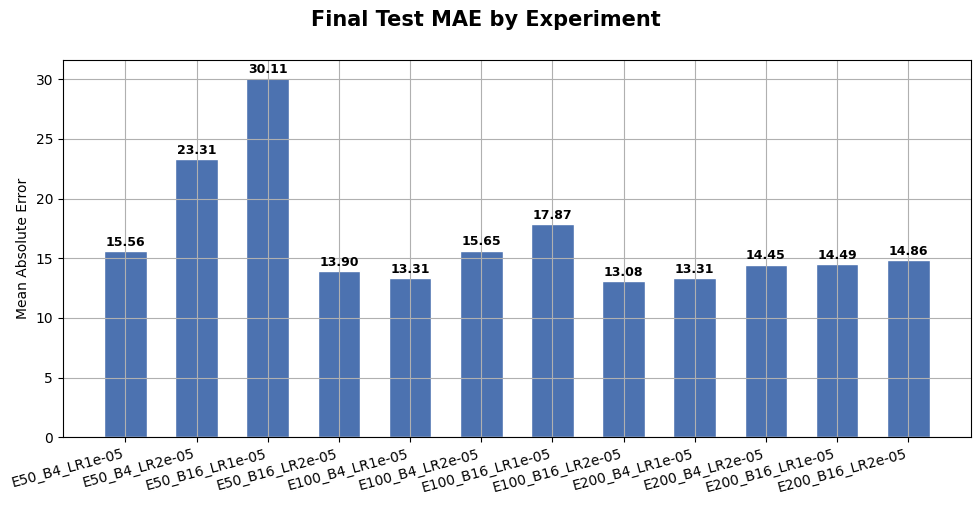

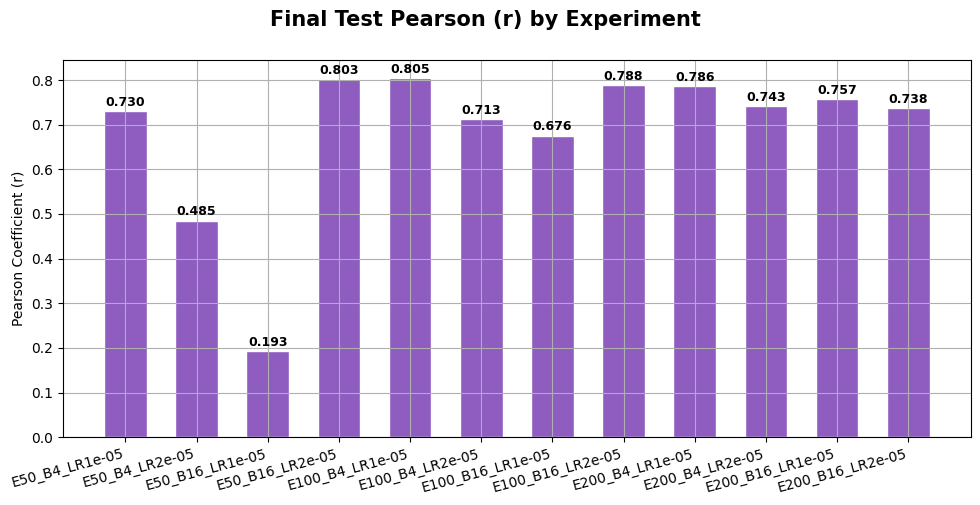

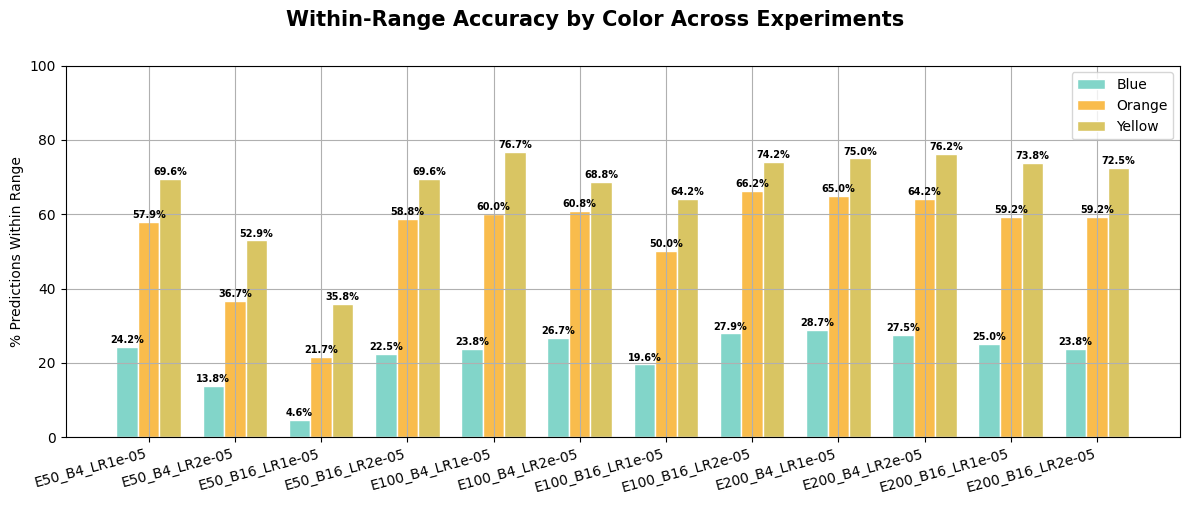

In [88]:
# Cross-Experiment Graphs (All)
num_experiments = np.arange(len(exp_names))

# Final Test MAE Comparison
plt.figure(figsize = (10, 5))
bars = plt.bar(num_experiments, [exp["test_mae"] for exp in experiments],
               color = "#4C72B0", width = 0.6, edgecolor = "white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{bar.get_height():.2f}", ha = "center", va = "bottom", fontweight = "bold", fontsize = 9)

plt.xticks(num_experiments, exp_names, rotation = 15, ha = "right")
plt.ylabel("Mean Absolute Error")
plt.suptitle("Final Test MAE by Experiment", fontsize = 15, fontweight = "bold", y = 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{graphs_directory}/all_test_mae.png", bbox_inches = "tight")
plt.show()


# Final Test Pearson (r) Comparison
plt.figure(figsize = (10, 5))
bars = plt.bar(num_experiments, [exp["test_r"] for exp in experiments],
               color = "#8E5DBF", width = 0.6, edgecolor = "white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha = "center", va = "bottom", fontweight = "bold", fontsize = 9)

plt.xticks(num_experiments, exp_names, rotation = 15, ha = "right")
plt.ylabel("Pearson Coefficient (r)")
plt.suptitle("Final Test Pearson (r) by Experiment", fontsize = 15, fontweight = "bold", y = 1)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{graphs_directory}/all_test_r.png", bbox_inches = "tight")
plt.show()


# Within-Range Accuracy Grouped Bar Chart
width      = 0.25
blue_acc   = [exp["within_range"]["blue"]   for exp in experiments]
orange_acc = [exp["within_range"]["orange"] for exp in experiments]
yellow_acc = [exp["within_range"]["yellow"] for exp in experiments]

plt.figure(figsize = (12, 5))
bars1 = plt.bar(num_experiments - width, blue_acc,   width, label = "Blue",   color = "#82D5C9", edgecolor = "white")
bars2 = plt.bar(num_experiments,         orange_acc, width, label = "Orange", color = "#F9BC4C", edgecolor = "white")
bars3 = plt.bar(num_experiments + width, yellow_acc, width, label = "Yellow", color = "#D9C563", edgecolor = "white")

for bar in list(bars1) + list(bars2) + list(bars3):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{bar.get_height():.1f}%", ha = "center", va = "bottom", fontweight = "bold", fontsize = 7)

plt.xticks(num_experiments, exp_names, rotation = 15, ha = "right")
plt.ylabel("% Predictions Within Range")
plt.suptitle("Within-Range Accuracy by Color Across Experiments", fontsize = 15, fontweight = "bold", y = 1)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{graphs_directory}/all_color_range_acc.png", bbox_inches = "tight")
plt.show()